In [1]:
import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

## Categorical Plots

### Categorical Scatter Plot

- Stripplot
- Swarmplot

### Categorical Distribution Plots

- Boxplot
- Violinplot

### Categorical Estimate Plot -> for central tendency

- Barplot
- Pointplot
- Countplot

### Figure level function -> `catplot`

<Axes: xlabel='total_bill', ylabel='tip'>

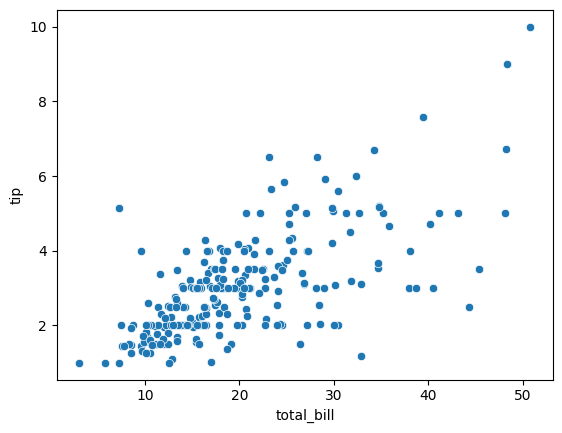

In [3]:
sns.scatterplot(data= tips , x ='total_bill' , y='tip')

<Axes: xlabel='day', ylabel='total_bill'>

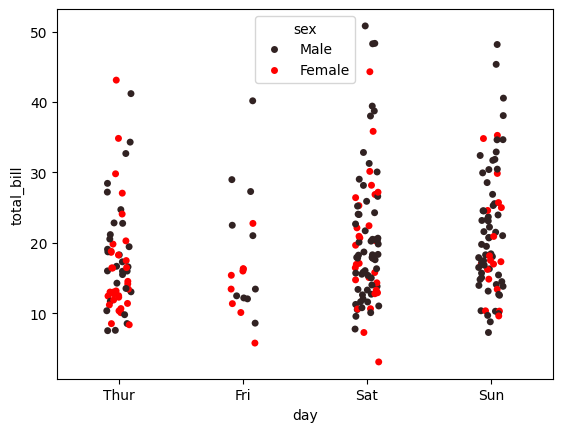

In [28]:
# scatter categorical plot (1 column numerical and 1 categorical) also called strip plot
sns.stripplot(data=tips,x='day' , y='total_bill',jitter=True,hue='sex',palette='dark:red')# jitter false reduce noice added by sns we can do jitter 0 - 1 0.5 , 0.6 etc

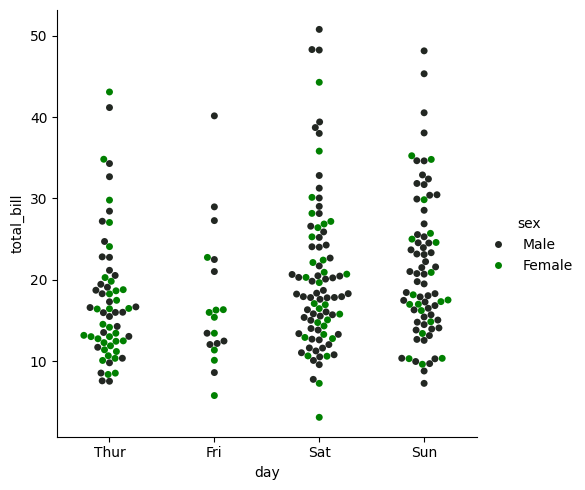

In [29]:
# swarm plot

sns.catplot(data=tips , x='day',y='total_bill',kind='swarm',hue='sex',palette='dark:green') # use algorithm that tells or shows the distribution of data# usefull ony for small data

# categorical distribution plot

### Boxplot

A boxplot is a standardized way of displaying the distribution of data based on a five number summary (“minimum”, first quartile [Q1], median, third quartile [Q3] and “maximum”). It can tell you about your outliers and what their values are. Boxplots can also tell you if your data is symmetrical, how tightly your data is grouped and if and how your data is skewed.

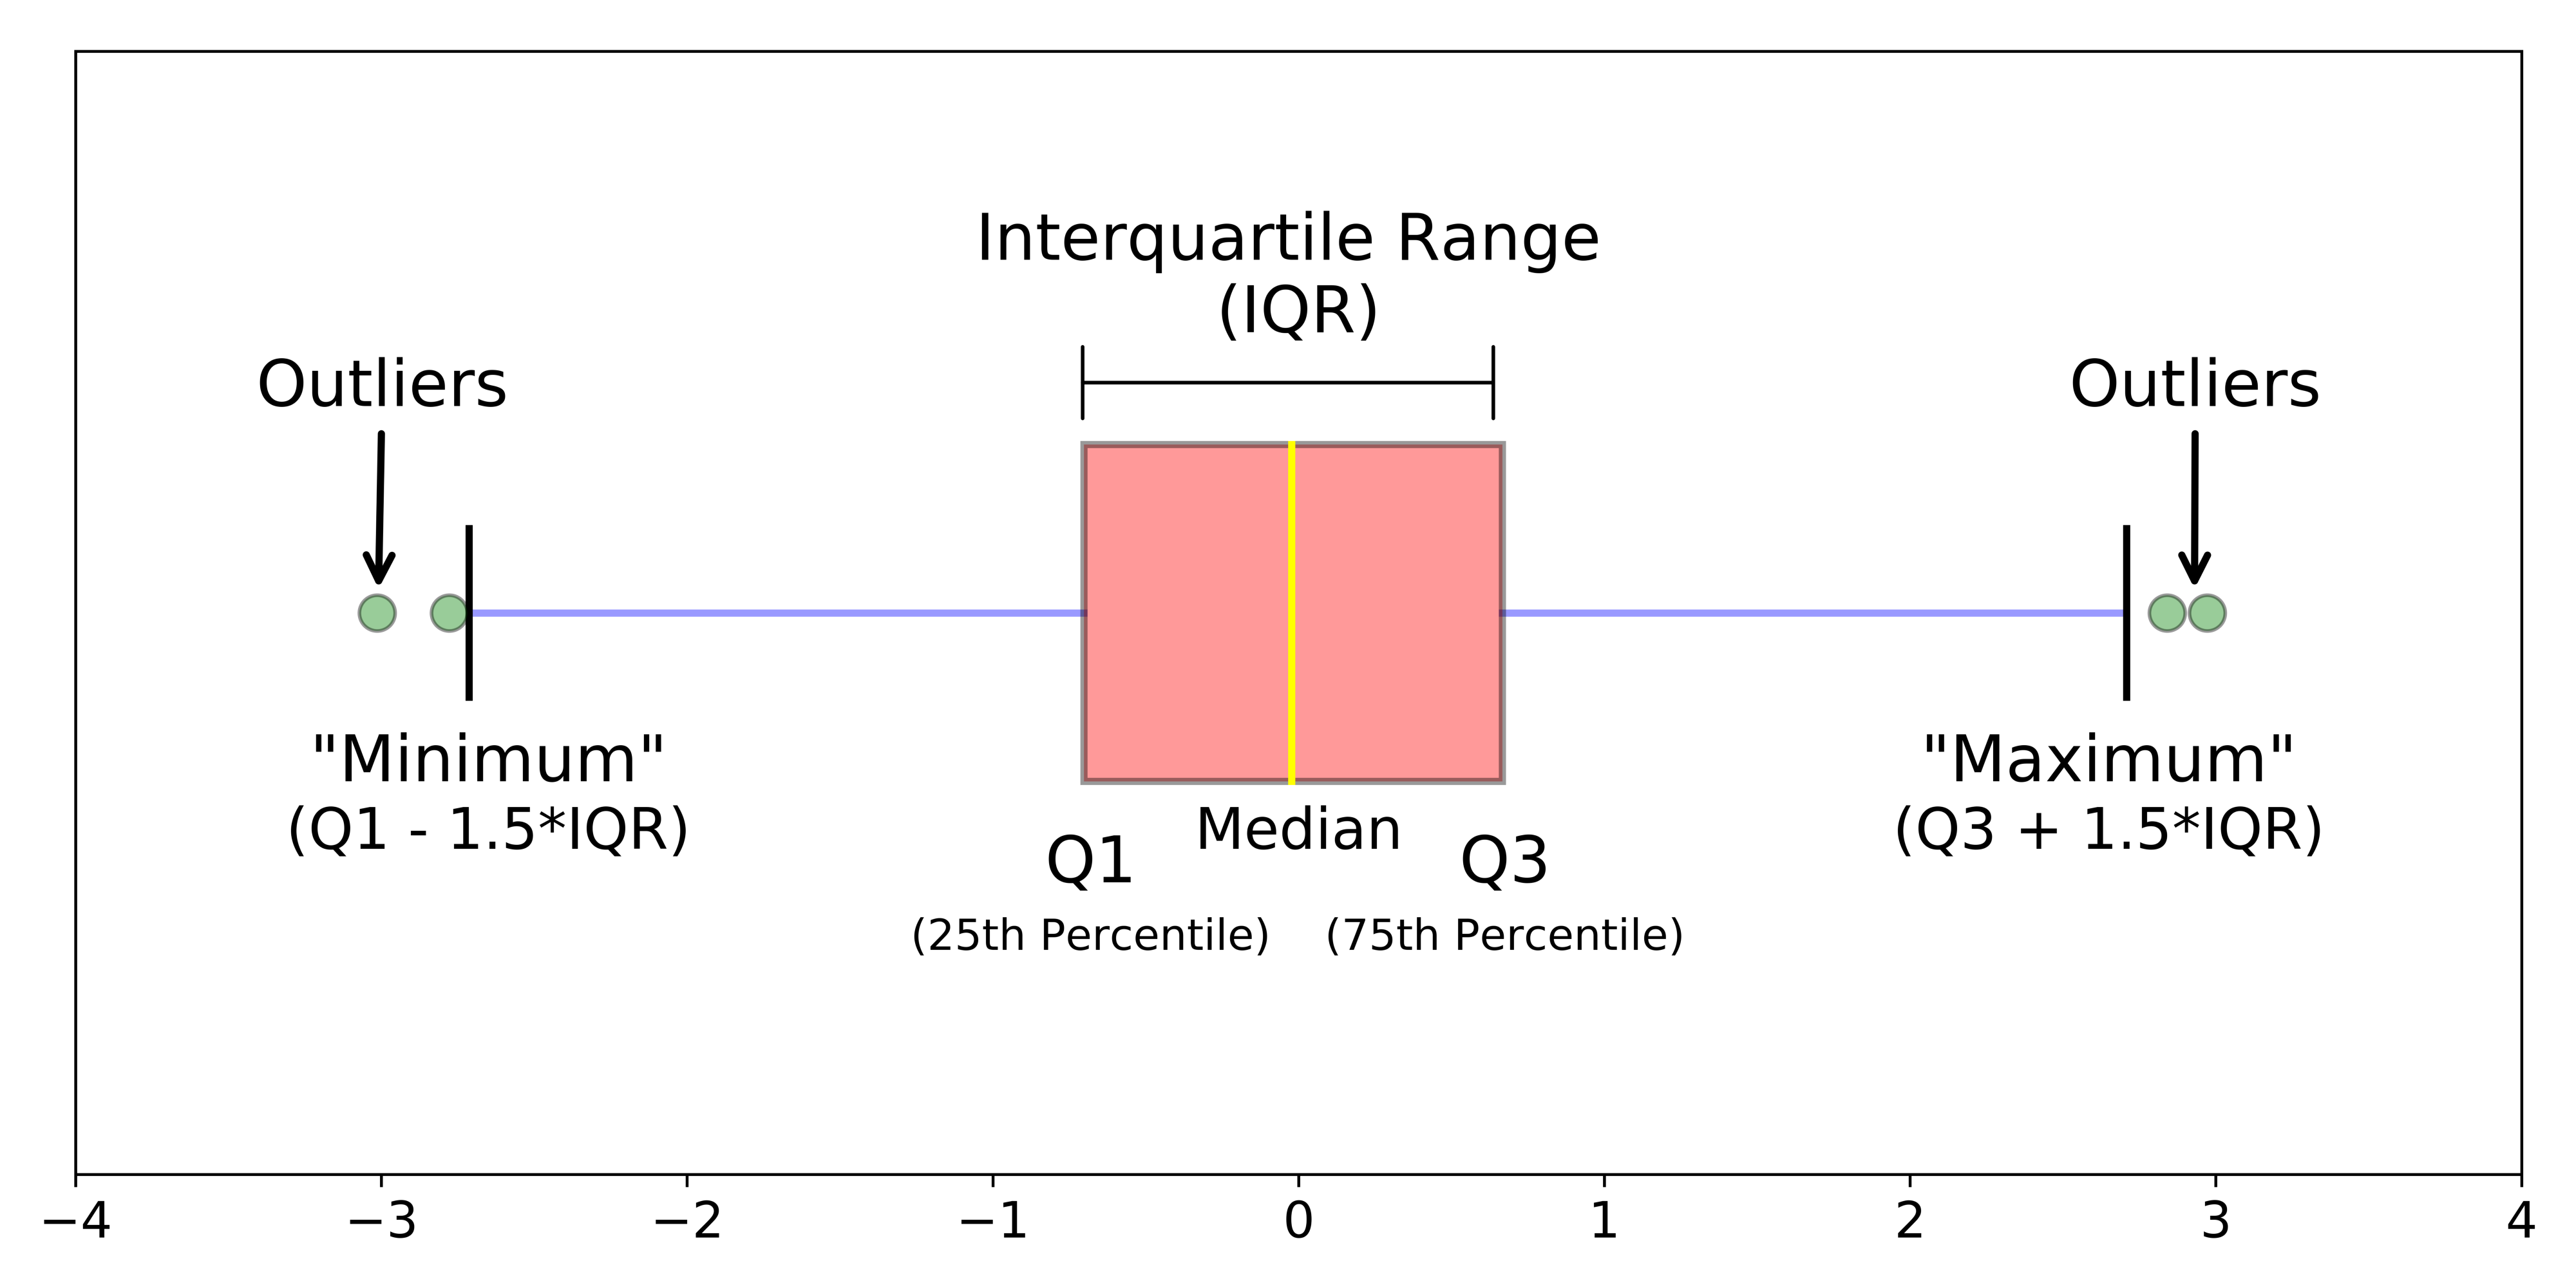

<Axes: xlabel='day', ylabel='total_bill'>

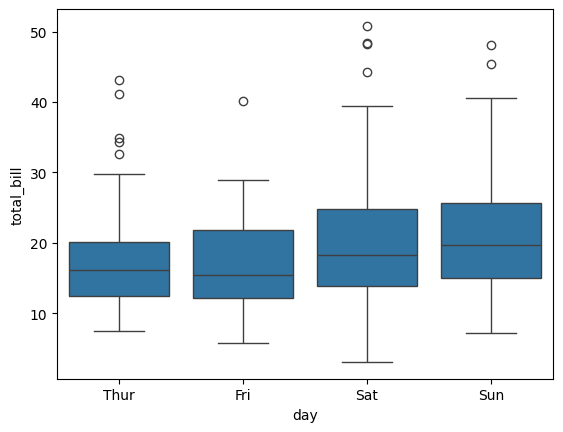

In [33]:
# boxplot

sns.boxplot(data=tips,x = 'day' , y='total_bill')

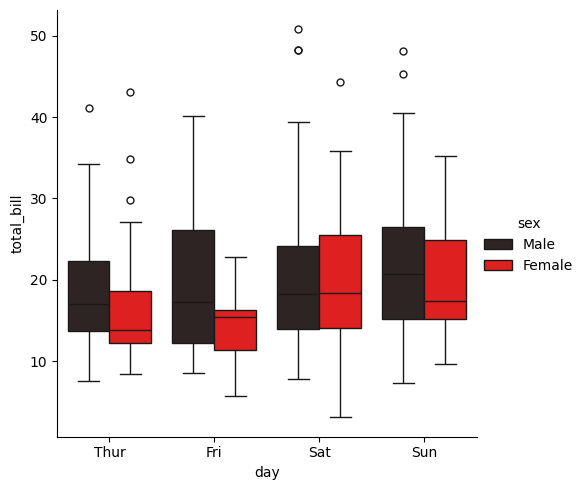

In [35]:
# using catplot
sns.catplot(data=tips,x = 'day' , y='total_bill',hue='sex',palette='dark:red',kind='box')


<Axes: ylabel='total_bill'>

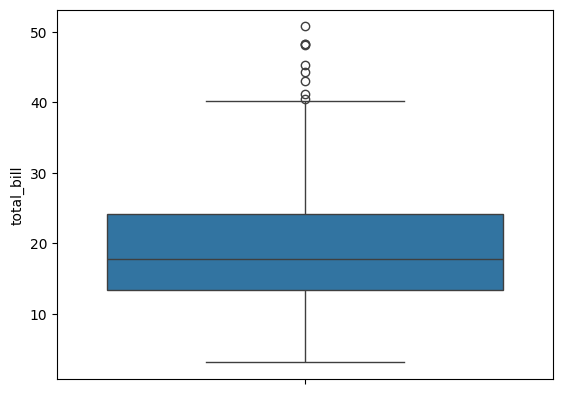

In [37]:
# single box plot on numerical column
sns.boxplot(data=tips, y='total_bill')

### Violinplot = (Boxplot + KDEplot)

<Axes: xlabel='sex', ylabel='total_bill'>

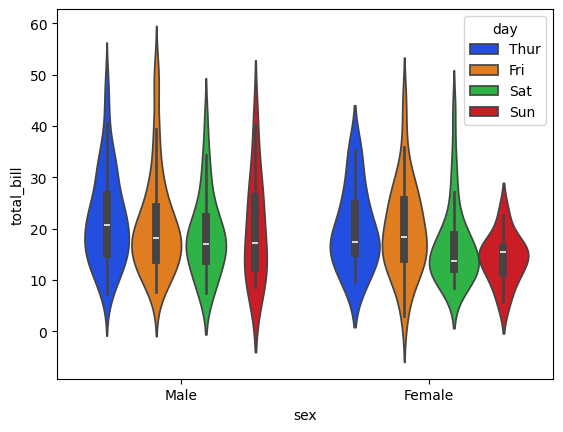

In [66]:
sns.violinplot(data=tips,x='sex',y='total_bill',hue='day',palette='bright')

<Axes: xlabel='day', ylabel='total_bill'>

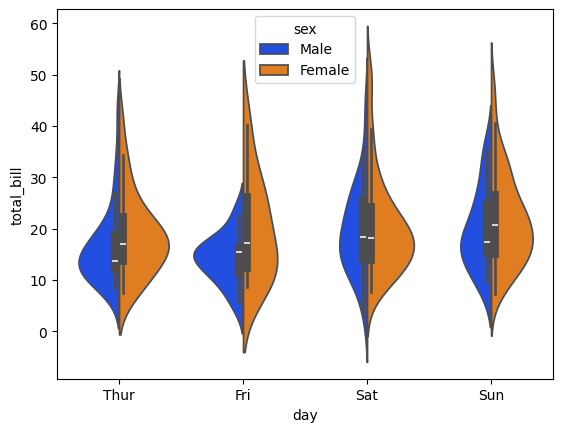

In [45]:
sns.violinplot(data=tips,x='day',y='total_bill',hue='sex',palette='bright',split=True) # split make side by side graph 

# barplot
# some issue with errorbar

<Axes: xlabel='sex', ylabel='total_bill'>

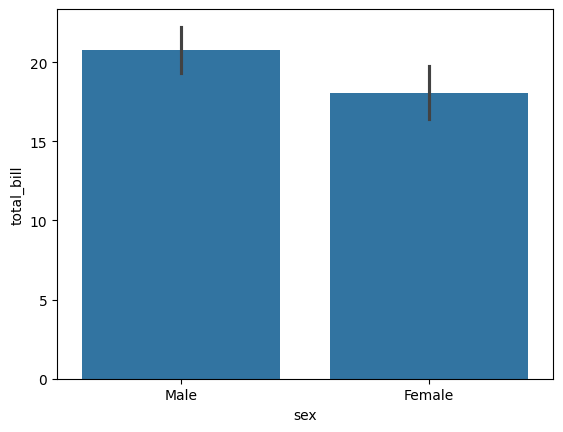

In [58]:
import numpy as np
sns.barplot(data=tips,x='sex',y='total_bill')

When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars

C:\Users\zaina\AppData\Local\Temp\ipykernel_12272\2295777144.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(data=tips,x='sex',y='total_bill',kind='bar', ci = None,hue='smoker',estimator=np.std) # etimator ci = None is use to calculate statistical  operation


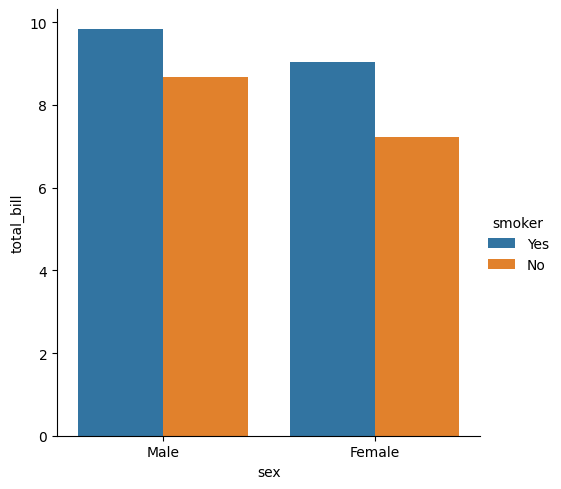

In [72]:
# graph showing std of smoker male
sns.catplot(data=tips,x='sex',y='total_bill',kind='bar', ci = None,hue='smoker',estimator=np.std) # etimator ci = None is use to calculate statistical  operation

C:\Users\zaina\AppData\Local\Temp\ipykernel_12272\759607823.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(data=tips,x='sex',y='total_bill',kind='point', ci=None,hue='smoker',estimator=np.std)


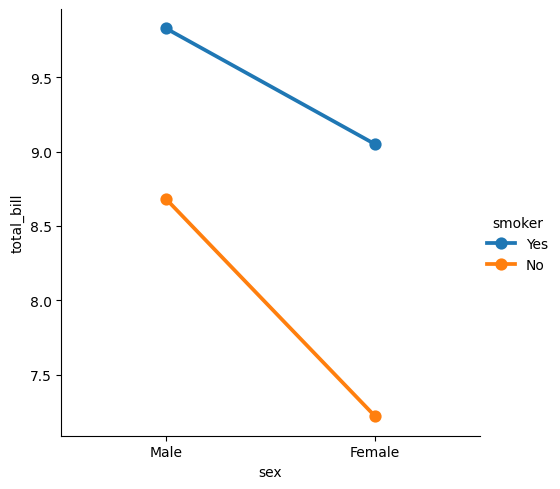

In [70]:
# point plot
sns.catplot(data=tips,x='sex',y='total_bill',kind='point', ci=None,hue='smoker',estimator=np.std)


<Axes: xlabel='sex', ylabel='count'>

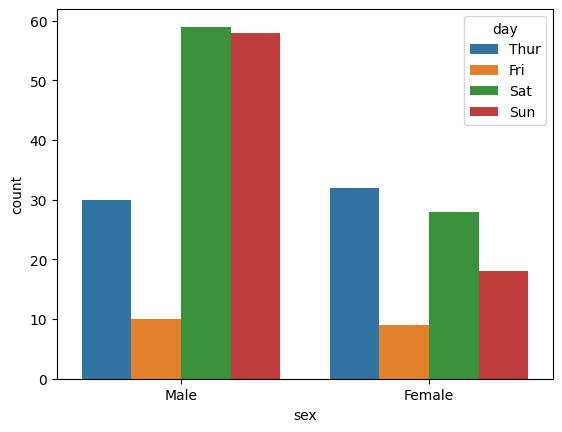

In [65]:
# countplot
sns.countplot(data=tips,x='sex',hue='day')

A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable

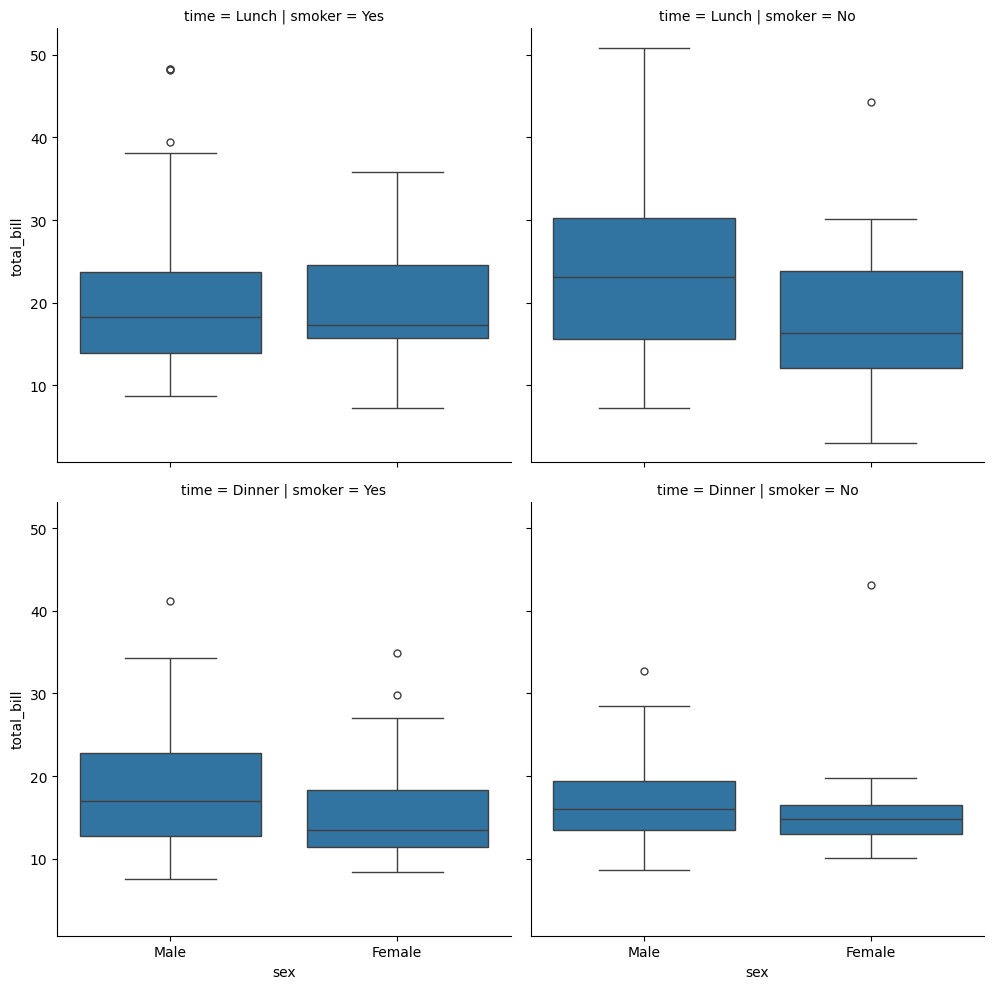

In [67]:
# faceting using catplot
sns.catplot(data=tips, x='sex',y='total_bill',col='smoker',kind='box',row='time')

### Regression Plots

- regplot
- lmplot

In the simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model y ~ x and plot the resulting regression line and a 95% confidence interval for that regression.

<Axes: xlabel='total_bill', ylabel='tip'>

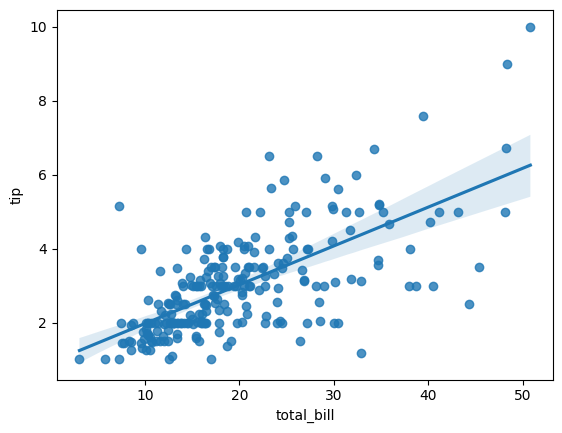

In [ ]:
#axis level func
# hue parameter are not available
sns.regplot(data=tips,x='total_bill',y='tip')

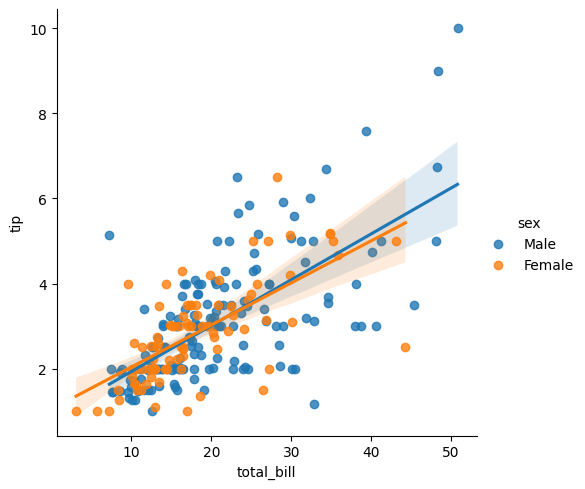

In [ ]:
#function level func
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

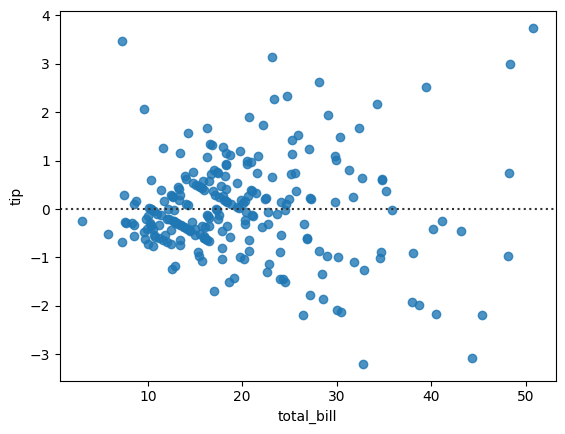

In [80]:
# residplot

sns.residplot(data=tips,x='total_bill',y='tip')

### A second way to plot Facet plots -> FacetGrid

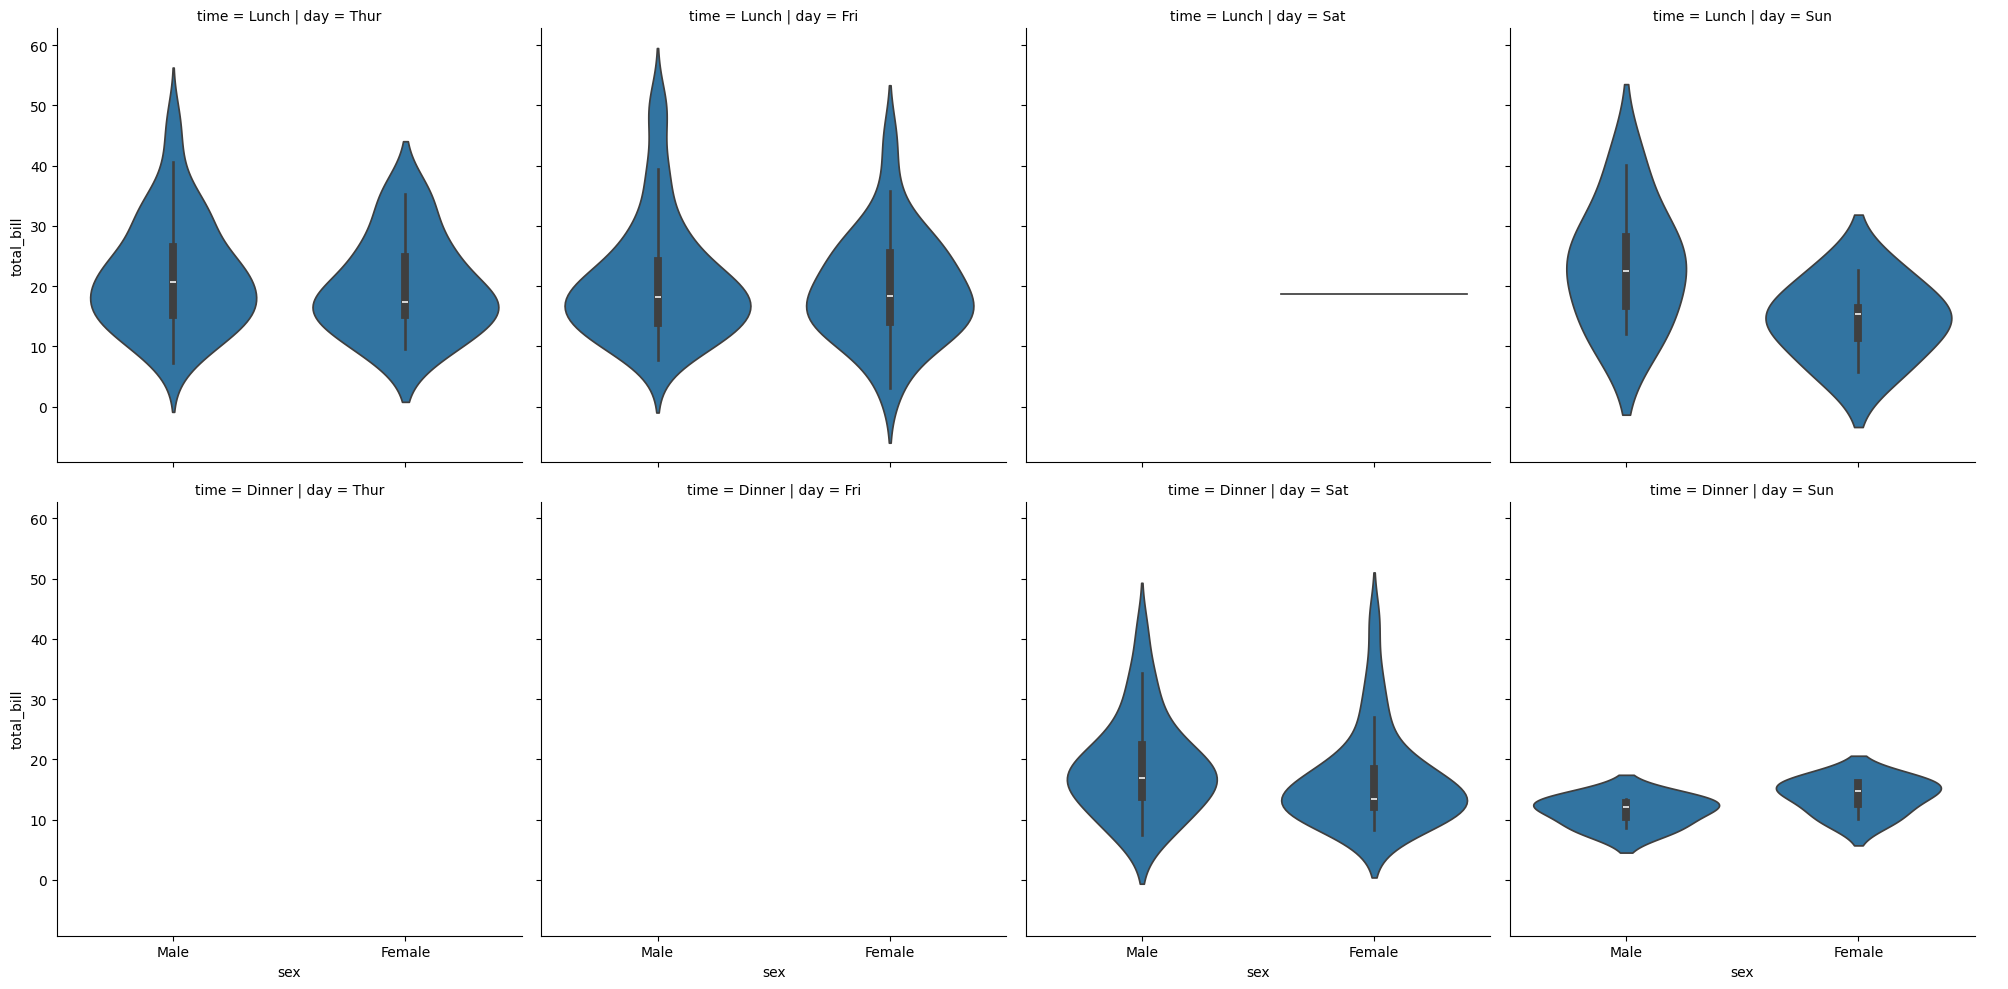

In [81]:
# figure level -> relplot -> displot -> catplot -> lmplot
sns.catplot(data=tips,x='sex',y='total_bill',kind='violin',col='day',row='time')

# Facetgrid 

c:\Users\zaina\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


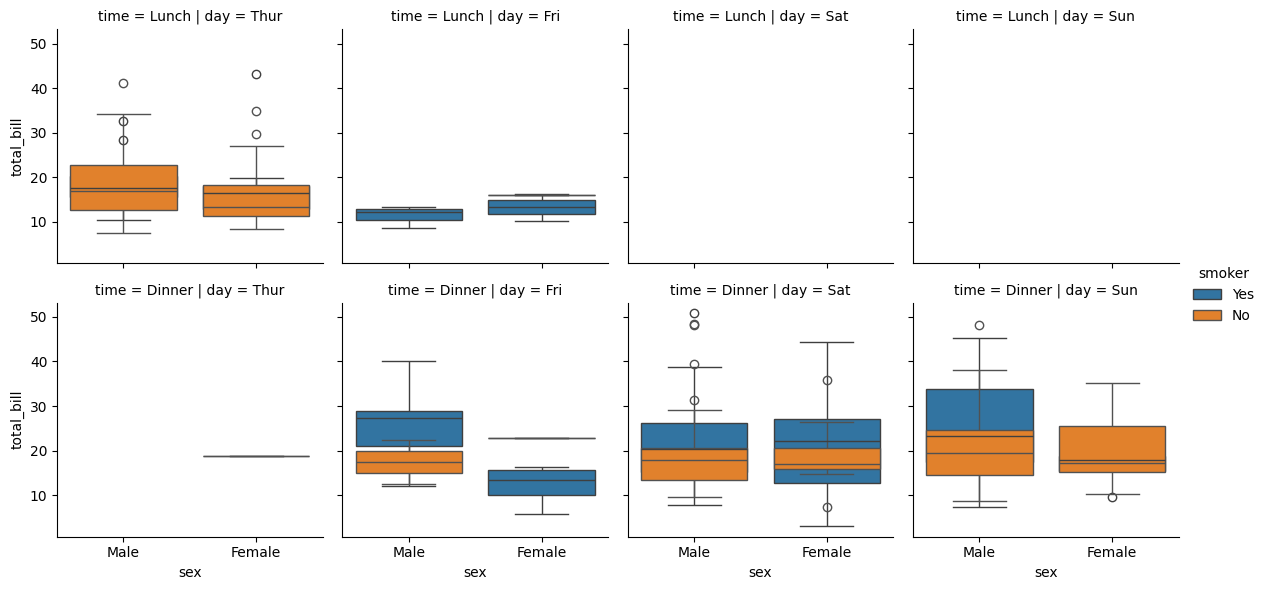

In [89]:
g =sns.FacetGrid(data=tips,col='day',row='time',hue='smoker')
g.map(sns.boxplot,'sex','total_bill')
g.add_legend()


### Plotting Pairwise Relationship (PairGrid Vs Pairplot)

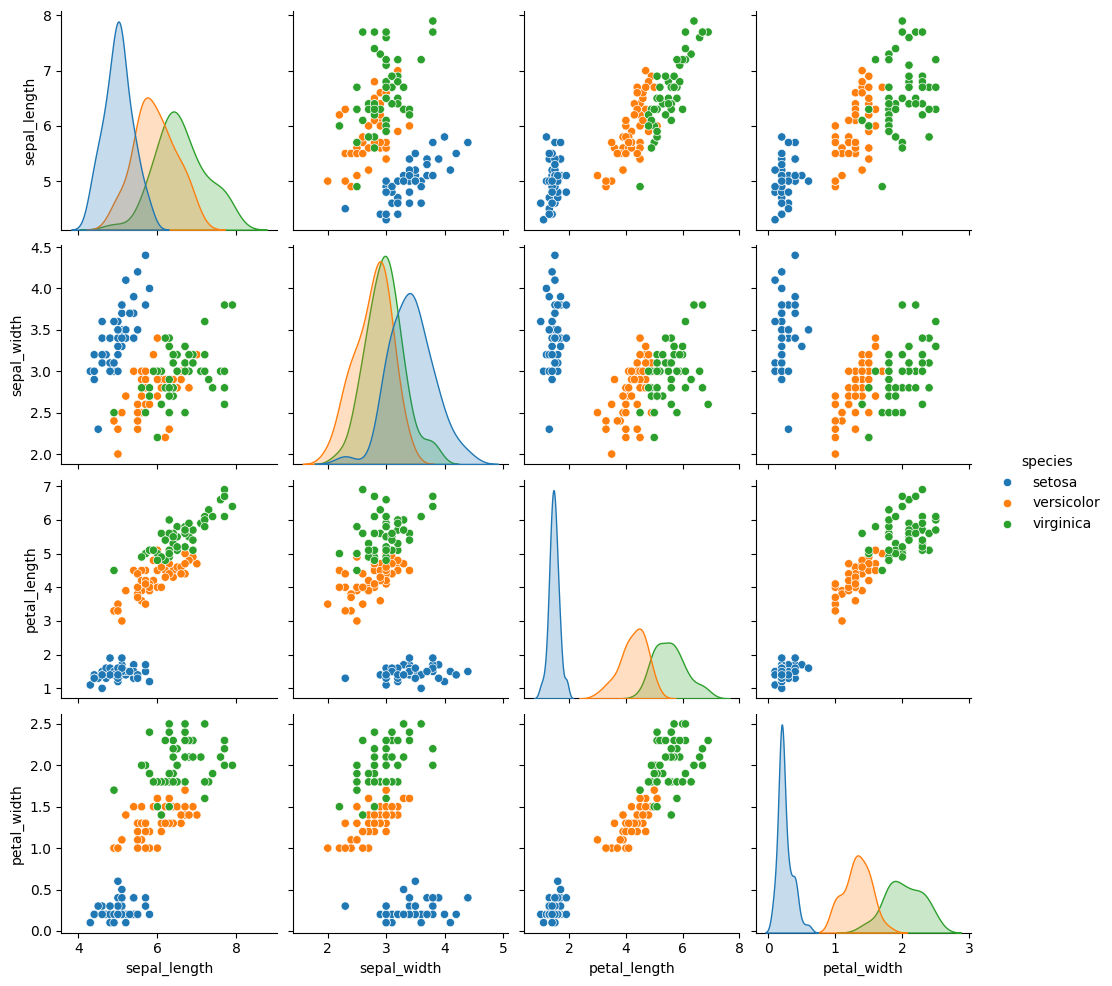

In [93]:
#pairplot
sns.pairplot(iris,hue='species')

# pairgrid

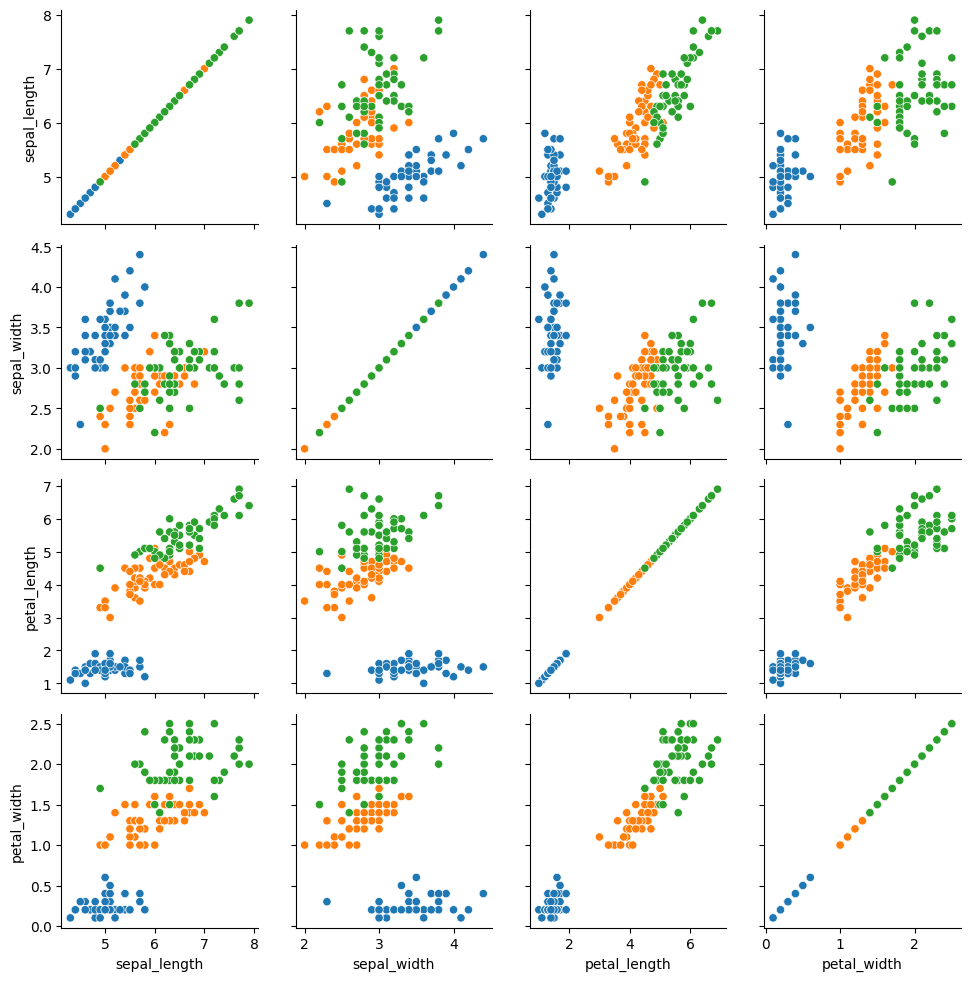

In [97]:
g = sns.PairGrid(data=iris,hue='species')
g.map(sns.scatterplot)

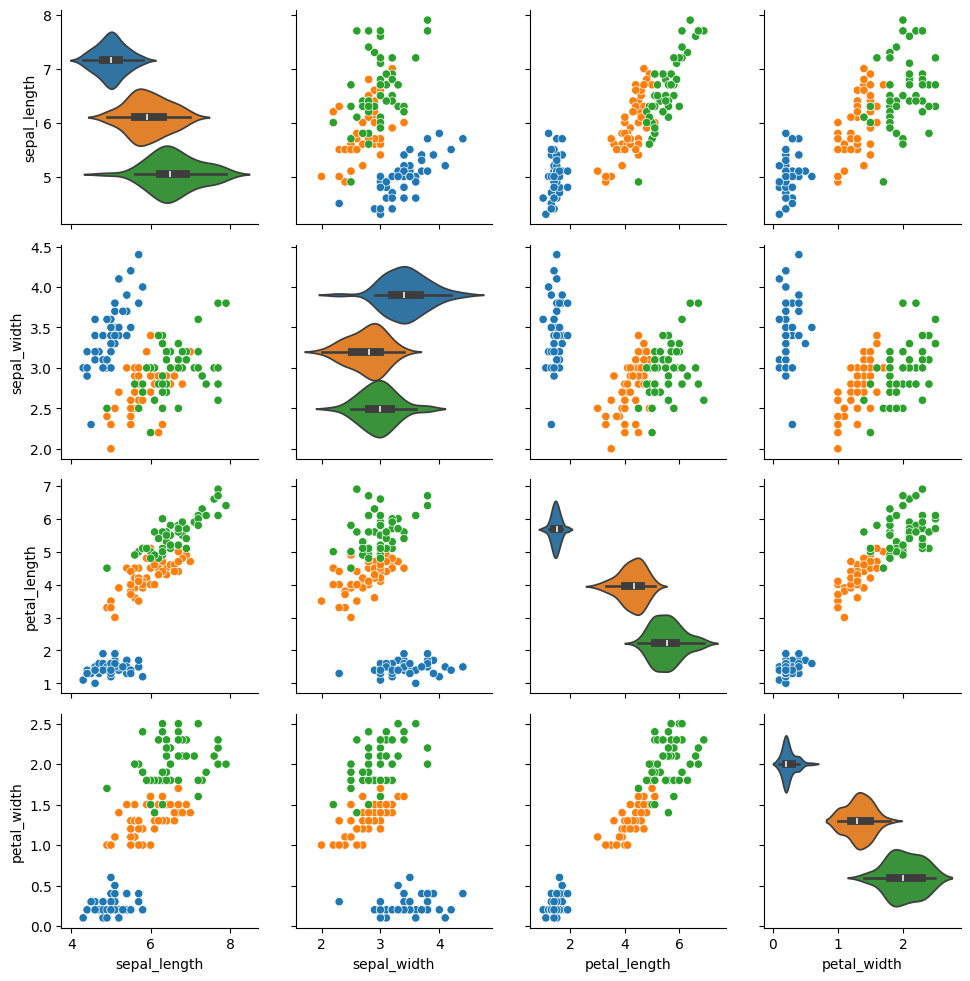

In [102]:
# map diagnol  --> map_offdiag
g = sns.PairGrid(data=iris,hue='species')

g.map_diag(sns.violinplot)
g.map_offdiag(sns.scatterplot)
# g.fig.suptitle("Iris Flower classification", fontsize=16)

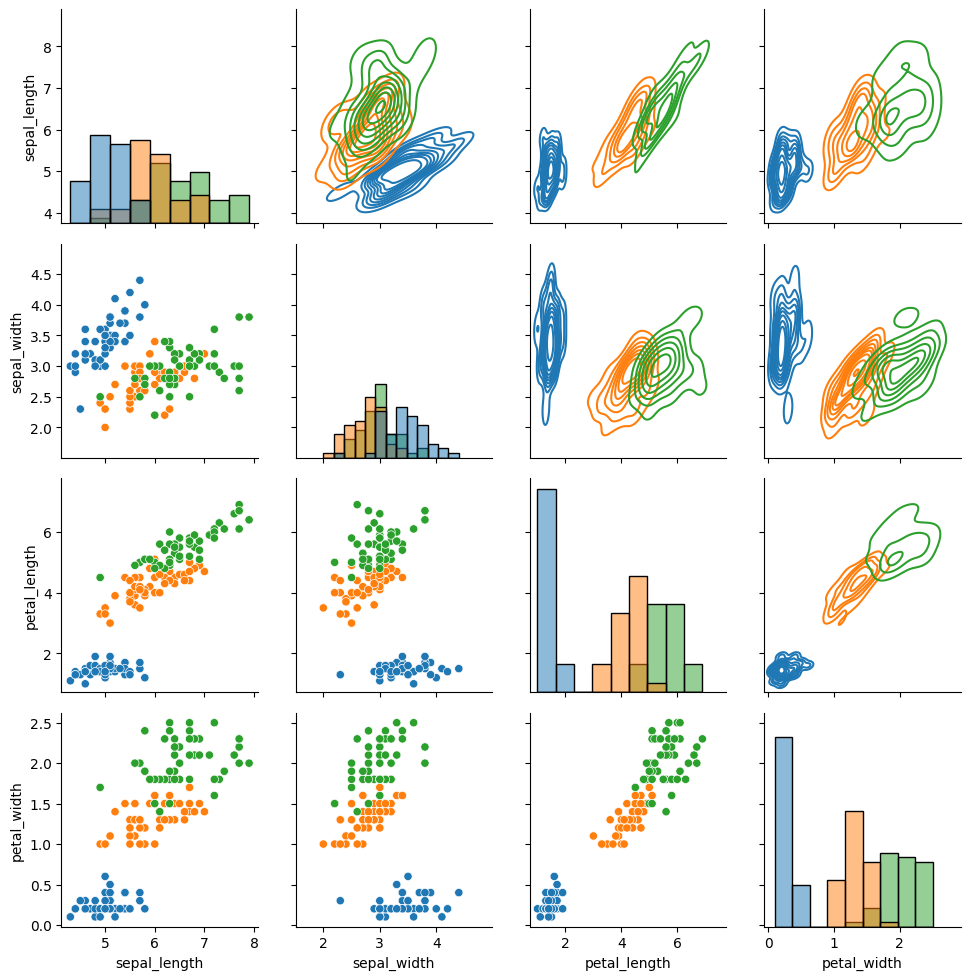

In [103]:
# map_diag -> map_upper -> map_lower
g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)

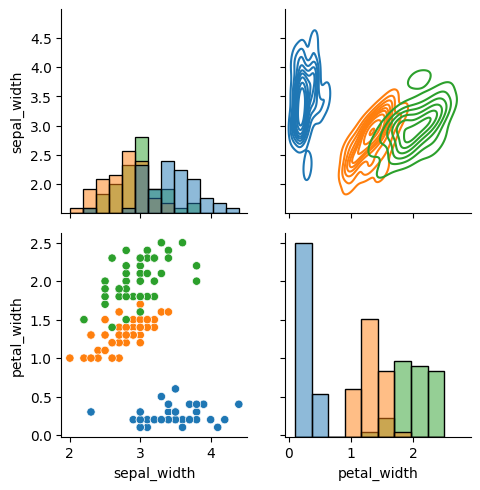

In [104]:
# vars
g = sns.PairGrid(data=iris,hue='species',vars=['sepal_width','petal_width'])
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)

# Joint plot  JointGrid

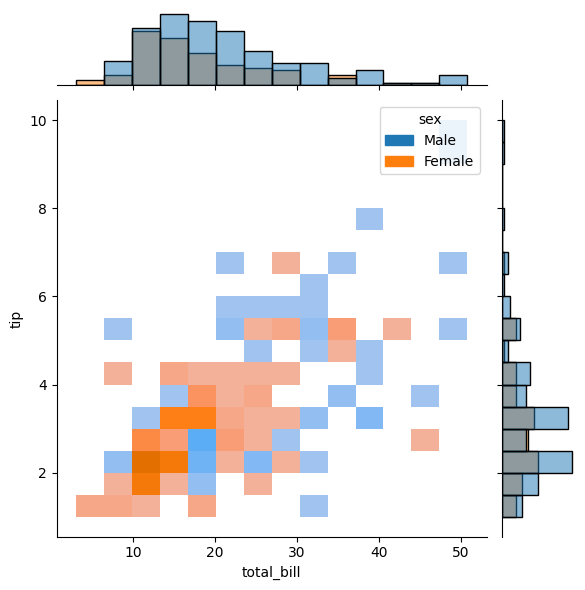

In [109]:
sns.jointplot(data=tips,x='total_bill',y='tip',kind='hist',hue='sex')

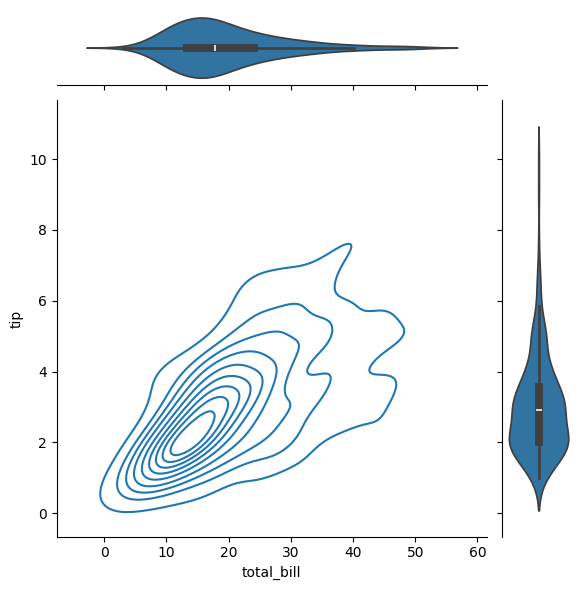

In [116]:
g = sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.kdeplot,sns.violinplot)

In [119]:
# get dataets name to check how many datsets are available in seaborn

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [121]:
sns.load_dataset('flights')

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
